# Floyd-Warshall on Planar Graphs

All-pairs shortest paths are fundamental in routing, geometric processing, and network analysis.
Floyd-Warshall solves
$$
d_{ij}^{(k)} = \min\!\big(d_{ij}^{(k-1)},\, d_{ik}^{(k-1)} + d_{kj}^{(k-1)}\big),
$$
and returns geodesic distances between every pair of nodes.

Here we use a **planar graph** built from random points and Delaunay edges, then extract shortest-path trees and paths along those edges.


## Planar graph from random points and Delaunay triangulation

We sample points in the unit square, create Delaunay triangles, and keep their edges as a sparse planar graph.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

from scipy.spatial import Delaunay
import ipywidgets as widgets
from IPython.display import display

OUT = Path("python/floyd-warshall"); OUT.mkdir(parents=True, exist_ok=True)
n = 75
pts = rng.uniform(0.05, 0.95, size=(n, 2))
tri = Delaunay(pts)

edges = set()
for t in tri.simplices:
    for a, b in [(t[0], t[1]), (t[1], t[2]), (t[2], t[0])]:
        if a > b:
            a, b = b, a
        edges.add((a, b))
edges = sorted(edges)

W = np.full((n, n), np.inf)
np.fill_diagonal(W, 0.0)
for i, j in edges:
    w = float(np.linalg.norm(pts[i] - pts[j]))
    W[i, j] = W[j, i] = w


## Floyd-Warshall and shortest-path tree extraction

We compute all-pairs distances and keep a `next` table to reconstruct routes.
From a root node, the shortest-path tree is the set of predecessor links implied by these geodesics.


In [2]:
D = W.copy()
NXT = np.full((n, n), -1, dtype=int)
for i in range(n):
    for j in range(n):
        if np.isfinite(W[i, j]) and i != j:
            NXT[i, j] = j

for k in range(n):
    Dik = D[:, k][:, None]
    Dkj = D[k, :][None, :]
    cand = Dik + Dkj
    mask = cand < D
    D[mask] = cand[mask]
    for i in np.where(mask.any(axis=1))[0]:
        js = np.where(mask[i])[0]
        NXT[i, js] = NXT[i, k]

def extract_path(i, j):
    if NXT[i, j] < 0:
        return []
    p = [i]
    while i != j:
        i = int(NXT[i, j])
        p.append(i)
        if len(p) > n + 3:
            return []
    return p

root = int(np.argmin(np.sum(pts, axis=1)))
tree_edges = set()
for j in range(n):
    if j == root:
        continue
    p = extract_path(root, j)
    for a, b in zip(p[:-1], p[1:]):
        if a > b:
            a, b = b, a
        tree_edges.add((a, b))


## Min-plus (tropical) remark

Floyd-Warshall can be interpreted as dynamic programming over the min-plus semiring:
addition is replaced by `min`, and multiplication by `+`.
This algebraic perspective explains why repeated relaxations converge to shortest-path closure.


## Static visualization: planar graph, shortest-path tree, and a sample route


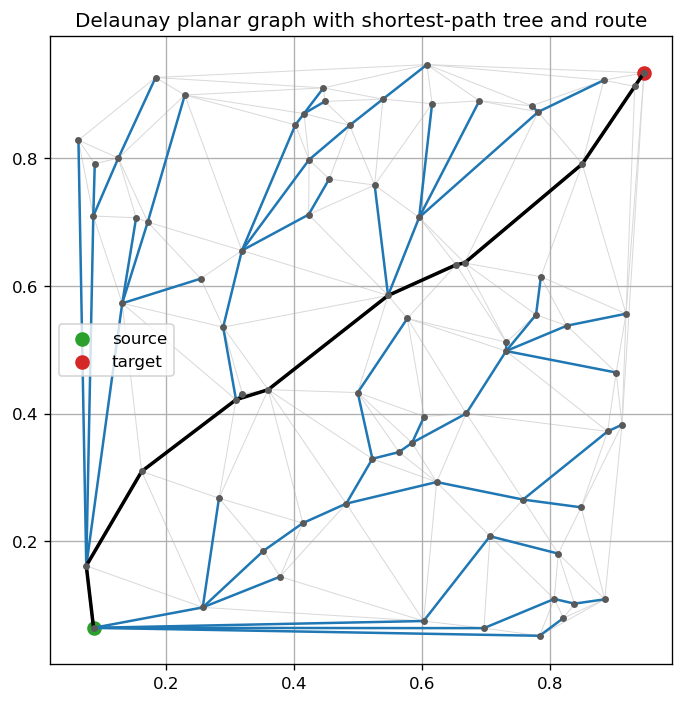

In [3]:
src = root
dst = int(np.argmax(np.linalg.norm(pts - pts[src], axis=1)))
path = extract_path(src, dst)

fig, ax = plt.subplots(figsize=(7.2, 6.8))
for i, j in edges:
    ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], color="0.85", lw=0.6, zorder=1)
for i, j in tree_edges:
    ax.plot([pts[i,0], pts[j,0]], [pts[i,1], pts[j,1]], color="tab:blue", lw=1.5, zorder=2)
if len(path) > 1:
    P = pts[path]
    ax.plot(P[:,0], P[:,1], color="k", lw=2.1, zorder=3)
ax.scatter(pts[:,0], pts[:,1], s=10, c="0.35", zorder=4)
ax.scatter(pts[src,0], pts[src,1], c="tab:green", s=60, label="source")
ax.scatter(pts[dst,0], pts[dst,1], c="tab:red", s=60, label="target")
ax.set_title("Delaunay planar graph with shortest-path tree and route")
ax.set_aspect("equal")
ax.legend()
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()


## Interactive: trace a shortest path on the same planar graph
